# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

from scipy.stats import wilcoxon
from numpy import matlib
from scipy.stats.distributions import chi2
from sklearn.model_selection import KFold

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [116]:
def getI(features, dt, nt):
    time_line = np.arange(nt)*dt
    baseline = features["baseline"]
    features["I"] = np.zeros((len(time_line), features["bump_center"][0].shape[0]))+baseline
    for i in range(len(features["bump_amp"])):
        stimulus = (features["bump_amp"][i])*np.exp(-((time_line[:, np.newaxis]- \
                       features["bump_center"][i][np.newaxis, :])/features["bump_wid"][i])**2)
        features["I"] += stimulus

In [133]:
def EIF_simulator():
    ntrial = 100
    nneuron = 20
    dt = 0.1
    ndt = int(1/dt)
    nt = 500*ndt
    noise_amp = 1

    J = np.zeros((nneuron, nneuron)) # From row i to column j
    nneuron_part = int(nneuron/2)
    J[0:nneuron_part,nneuron_part:] = 0.0
    J[0:nneuron_part,0:nneuron_part] = 0.0
    J[nneuron_part:,nneuron_part:] = 0.0

    baseline = 0.0
    bump_amp = 0.5
    bump_wid = 30
    source = {"baseline": baseline, 
              "bump_center": [np.nan,np.nan], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    target = {"baseline": baseline, 
              "bump_center": [np.nan,np.nan], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    bump_center_mean1 = [50, 60]
    bump_center_cov1 = np.array([[100, 100], [100, 100]])
    bump_center_mean2 = [250, 260]
    bump_center_cov2 = np.array([[2500, 2500], [2500, 2500]])
    bump_centers1 = np.random.multivariate_normal(bump_center_mean1, bump_center_cov1, size=ntrial)
    bump_centers2 = np.random.multivariate_normal(bump_center_mean2, bump_center_cov2, size=ntrial)
    source["bump_center"] = [bump_centers1[:, 0], bump_centers2[:, 0]]
    target["bump_center"] = [bump_centers1[:, 1], bump_centers2[:, 1]]
    getI(source, dt, nt)
    getI(target, dt, nt)
    I_ext = 0.0*np.ones((nt, nneuron, ntrial))
    I_ext[:,:nneuron_part,:] = np.repeat(source["I"][:,np.newaxis,:],nneuron_part, axis=1)
    I_ext[:,:nneuron_part,:] = np.repeat(target["I"][:,np.newaxis,:],nneuron_part, axis=1)

    # Unit: mV or ms
    tau = 15
    EL = -60
    VT = -50
    Vth = -10
    Vre = -65
    DltT = 2
    tau_ref = 1
    tau_d = 5
    tau_r = 1

    nsyn_func = 3*tau_d*ndt
    syn_time_line = np.arange(nsyn_func)
    syn_func = (np.exp(-syn_time_line*dt/tau_d)-np.exp(-syn_time_line*dt/tau_r))[:, np.newaxis]
    ntau_ref = tau_ref*ndt
    V_rcd = np.zeros((nt, nneuron, ntrial))
    I_rcd = np.zeros((nt+nsyn_func+1, nneuron, ntrial))
    spikes_rcd = np.zeros((nt, nneuron, ntrial))

    for itrial in range(ntrial):
        V = Vre*np.ones((nt, nneuron))
        I_syn = np.zeros((nt+nsyn_func+1, nneuron))
        spikes = np.zeros((nt, nneuron))

        for t in range(1, nt):

            I_leak = -dt/tau*(V[t-1,:]-EL) + dt/tau*DltT*np.exp((V[t-1,:]-VT)/DltT)
            I_noise = np.random.normal(0, noise_amp**2, nneuron)
            dV = I_leak + I_noise + I_syn[t,:] + I_ext[t,:,itrial]
            V[t,:] = V[t-1,:] + dV

            spikes[t,:] = (V[t,:]>=Vth).astype(int)
            I_syn[(t+1):(t+nsyn_func+1),:] += spikes[t:(t+1),:]@J*syn_func

            in_ref = ((spikes[max(0,t-ntau_ref):(t+1),:].sum(axis=0))>0).astype(int)
            V[t,:] += in_ref*(Vre-V[t,:])

        V_rcd[:,:,itrial] = V
        I_rcd[:,:,itrial] = I_syn
        spikes_rcd[:,:,itrial] = spikes

    spikes_rcd = spikes_rcd.reshape((int(nt/ndt),ndt,nneuron,ntrial), order='C').sum(axis=1)
    return spikes_rcd

spikes_rcd = EIF_simulator()

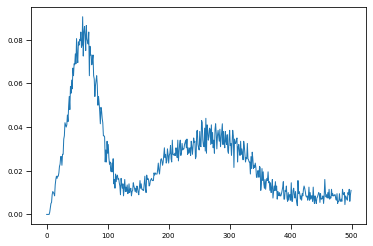

In [134]:
plt.plot(spikes_rcd.mean(axis=(1,2)))

# Fit the two methods for 100 times

In [135]:
ntimes = 10
nfold = 10
penalty = 1e4
penalty_pop = 1e3
num = 20
num_pop = num
peaks_max = 7

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator()
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")

# result = wilcoxon( test_nll_full, test_nll_nest, alternative='less'),\
#             likelihood_ratio_test(nll_diff, ntimes*nneuron*3)
# result_pop = wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less'),\
#                 likelihood_ratio_test(nll_diff_pop, ntimes*3)

100%|███████████████████████████████████| 10/10 [36:01<00:00, 216.10s/it]


In [136]:
result, result_pop

([WilcoxonResult(statistic=2417.0, pvalue=0.3551924957522084),
  WilcoxonResult(statistic=2417.0, pvalue=0.3551924957522084),
  WilcoxonResult(statistic=2414.0, pvalue=0.35135899083938815),
  WilcoxonResult(statistic=2316.0, pvalue=0.23619065827716224),
  WilcoxonResult(statistic=2224.0, pvalue=0.1503494522838097),
  WilcoxonResult(statistic=2310.0, pvalue=0.22988068600039868),
  WilcoxonResult(statistic=2545.0, pvalue=0.5274122567214328),
  WilcoxonResult(statistic=2450.0, pvalue=0.39825193550176236),
  WilcoxonResult(statistic=2529.0, pvalue=0.5054865996469117),
  WilcoxonResult(statistic=3342.0, pvalue=0.9975160773178945)],
 [WilcoxonResult(statistic=30.0, pvalue=0.615234375),
  WilcoxonResult(statistic=30.0, pvalue=0.615234375),
  WilcoxonResult(statistic=32.0, pvalue=0.6875),
  WilcoxonResult(statistic=52.0, pvalue=0.9970703125),
  WilcoxonResult(statistic=40.0, pvalue=0.9033203125),
  WilcoxonResult(statistic=40.0, pvalue=0.9033203125),
  WilcoxonResult(statistic=25.0, pvalue=0.4

调参：调出一个single neuron positive但是population 不positive的setting

```
{
penalty = 1e4
penalty_pop = 1e3
```
}


<AxesSubplot:ylabel='Count'>

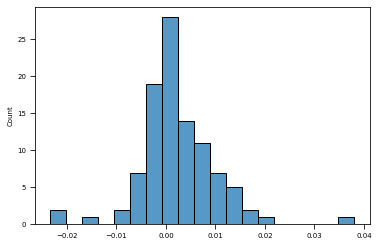

In [137]:
sns.histplot(np.array(test_nll_full)-np.array(test_nll_nest))

<AxesSubplot:ylabel='Count'>

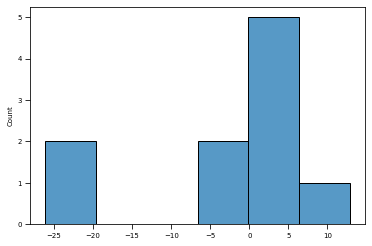

In [138]:
sns.histplot(np.array(test_nll_full_pop)-np.array(test_nll_nest_pop))

In [139]:
p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

(0.0, 1.0)

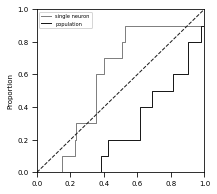

In [140]:
utils.use_pdf_plot()
plt.subplots(figsize=(3,3))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.plot([0,1], [0,1], '--', color='k')
# 1e5, 0.5e5 connect=0.007

plt.xlim([0,1])
plt.ylim([0,1])

# Check for penalty

## EIF neuron simulator

In [103]:
def getI(features, dt, nt):
    time_line = np.arange(nt)*dt
    baseline = features["baseline"]
    features["I"] = np.zeros(len(time_line))+baseline
    for i in range(len(features["bump_amp"])):
        stimulus = (features["bump_amp"][i])*np.exp(-((time_line-features["bump_center"][i])/features["bump_wid"][i])**2)
        features["I"] += stimulus

In [104]:
def EIF_simulator(ntrial = 100):
    nneuron = 20
    dt = 0.1
    ndt = int(1/dt)
    nt = 500*ndt
    noise_amp = 1

    J = np.zeros((nneuron, nneuron)) # From row i to column j
    nneuron_part = int(nneuron/2)
    J[0:nneuron_part,nneuron_part:] = 0.0
    J[0:nneuron_part,0:nneuron_part] = 0.0
    J[nneuron_part:,nneuron_part:] = 0.0

    baseline = 0.0
    bump_amp = 0.5
    bump_wid = 30
    source = {"baseline": baseline, 
              "bump_center": [50,250], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    target = {"baseline": baseline, 
              "bump_center": [70,270], 
              "bump_amp": [bump_amp,bump_amp], 
              "bump_wid": [bump_wid,bump_wid]}
    getI(source, dt, nt)
    getI(target, dt, nt)
    I_ext = 0.0*np.ones((nt, nneuron))
    I_ext[:,:nneuron_part] = np.repeat(source["I"][:,np.newaxis],nneuron_part, axis=1)
    I_ext[:,nneuron_part:] = np.repeat(target["I"][:,np.newaxis],nneuron_part, axis=1)

    # Unit: mV or ms
    tau = 15
    EL = -60
    VT = -50
    Vth = -10
    Vre = -65
    DltT = 2
    tau_ref = 1
    tau_d = 5
    tau_r = 1

    nsyn_func = 3*tau_d*ndt
    syn_time_line = np.arange(nsyn_func)
    syn_func = (np.exp(-syn_time_line*dt/tau_d)-np.exp(-syn_time_line*dt/tau_r))[:, np.newaxis]
    ntau_ref = tau_ref*ndt
    V_rcd = np.zeros((nt, nneuron, ntrial))
    I_rcd = np.zeros((nt+nsyn_func+1, nneuron, ntrial))
    spikes_rcd = np.zeros((nt, nneuron, ntrial))

    for itrial in range(ntrial):
        V = Vre*np.ones((nt, nneuron))
        I_syn = np.zeros((nt+nsyn_func+1, nneuron))
        spikes = np.zeros((nt, nneuron))

        for t in range(1, nt):

            I_leak = -dt/tau*(V[t-1,:]-EL) + dt/tau*DltT*np.exp((V[t-1,:]-VT)/DltT)
            I_noise = np.random.normal(0, noise_amp**2, nneuron)
            dV = I_leak + I_noise + I_syn[t,:] + I_ext[t,:]
            V[t,:] = V[t-1,:] + dV

            spikes[t,:] = (V[t,:]>=Vth).astype(int)
            I_syn[(t+1):(t+nsyn_func+1),:] += spikes[t:(t+1),:]@J*syn_func

            in_ref = ((spikes[max(0,t-ntau_ref):(t+1),:].sum(axis=0))>0).astype(int)
            V[t,:] += in_ref*(Vre-V[t,:])

        V_rcd[:,:,itrial] = V
        I_rcd[:,:,itrial] = I_syn
        spikes_rcd[:,:,itrial] = spikes

    spikes_rcd = spikes_rcd.reshape((int(nt/ndt),ndt,nneuron,ntrial), order='C').sum(axis=1)
    return spikes_rcd

spikes_rcd = EIF_simulator()

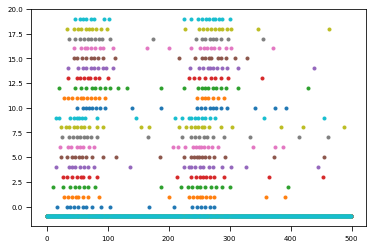

In [105]:
plt.plot(spikes_rcd[:,:,0]*np.arange(1,nneuron+1)-1, '.')

## Fit the two methods for 100 times

In [111]:
ntimes = 10
nfold = 10
penalty = 1e4
penalty_pop = 0.1e4
num = 20
num_pop = num
peaks_max = 7

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator()
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=20, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=3, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=True)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                                 method='mine', penalty=penalty_pop, verbose=False)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")

# result = wilcoxon( test_nll_full, test_nll_nest, alternative='less'),\
#             likelihood_ratio_test(nll_diff, ntimes*nneuron*3)
# result_pop = wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less'),\
#                 likelihood_ratio_test(nll_diff_pop, ntimes*3)

100%|███████████████████████████████| 100/100 [5:58:27<00:00, 215.07s/it]


In [112]:
result, result_pop

([WilcoxonResult(statistic=1147.0, pvalue=1.0791271206427418e-06),
  WilcoxonResult(statistic=1147.0, pvalue=1.0791271206427418e-06),
  WilcoxonResult(statistic=2460.0, pvalue=0.4115766487998047),
  WilcoxonResult(statistic=1948.0, pvalue=0.023632745481828563),
  WilcoxonResult(statistic=2135.0, pvalue=0.0899688809714419),
  WilcoxonResult(statistic=2234.0, pvalue=0.15852159490605128),
  WilcoxonResult(statistic=3038.0, pvalue=0.961122277904502),
  WilcoxonResult(statistic=2889.0, pvalue=0.8946331025313413),
  WilcoxonResult(statistic=2278.0, pvalue=0.19786658192609363),
  WilcoxonResult(statistic=1747.0, pvalue=0.003736276073822523),
  WilcoxonResult(statistic=2109.0, pvalue=0.07630928019131576),
  WilcoxonResult(statistic=3310.0, pvalue=0.996523479278238),
  WilcoxonResult(statistic=2025.0, pvalue=0.04279240059487246),
  WilcoxonResult(statistic=1960.0, pvalue=0.02602901684284186),
  WilcoxonResult(statistic=2565.0, pvalue=0.5546952423561289),
  WilcoxonResult(statistic=3294.0, pvalu

In [113]:
p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

In [114]:
np.mean(p), np.mean(p_pop)

(0.45507338172202344, 0.574384765625)

(0.0, 1.0)

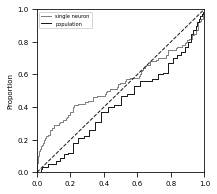

In [115]:
utils.use_pdf_plot()
plt.subplots(figsize=(3,3))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.plot([0,1], [0,1], '--', color='k')
# 1e5, 0.5e5 connect=0.007

plt.xlim([0,1])
plt.ylim([0,1])